# Data_Cleaning_Automation

### Install openpyxl library

In [1]:
# Install openpyxl library to enable Excel file generation automation
!pip install openpyxl

#### Import libraries

In [2]:
# Import core automation and processing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Data & Setup Automated Cleaning

#### Load the dataset

In [3]:
# Load the dataset (Change the filename if you have a different name)
raw_file = 'supermarket_sales.csv'
df = pd.read_csv(raw_file)

In [4]:
# Automated Null/Missing Value Treatment
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

In [5]:
# Automated Duplicate Detection and Removal
print(f"Initial Duplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Cleaned Data Duplicate Rows: {df.duplicated().sum()}")

Initial Duplicate Rows: 0
Cleaned Data Duplicate Rows: 0


In [6]:
# Generate Automated Data Insights Report to an Excel file
report_filename = 'Automated_Excel_Report.xlsx'
df.to_excel(report_filename, index=False, sheet_name='Cleaned Data')
print(f"\nSuccess: Cleaned data exported automatically to {report_filename}!")


Success: Cleaned data exported automatically to Automated_Excel_Report.xlsx!


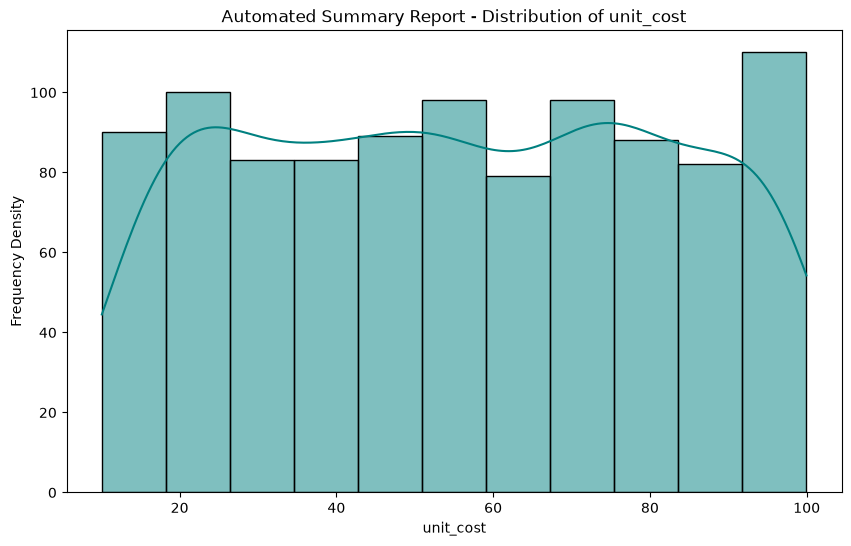

Success: Visual chart summary saved automatically as Automated_Visual_Summary.png!


In [7]:
# Generate Graphical Summary Report and Save as Image
numeric_cols = df.select_dtypes(include=['number']).columns
target_col = 'Total' if 'Total' in df.columns else numeric_cols[0]

# --- सब कुछ एक ही सेल में होना चाहिए ---
plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], kde=True, color='teal')
plt.title(f'Automated Summary Report - Distribution of {target_col}')
plt.xlabel(target_col)
plt.ylabel('Frequency Density')

# Save the plot automatically as a report image file
chart_filename = 'Automated_Visual_Summary.png'
plt.savefig(chart_filename, bbox_inches='tight')
plt.show()
print(f"Success: Visual chart summary saved automatically as {chart_filename}!")